In [0]:
import pandas as pd

# Objective:
1. shape, dtypes, missing values, stats, distributions, correlations
2. Choose the right visualisation library for each situation
3. Reproduce the same chart in matplotlib, seaborn, plotly - understanding the trade-offs
4. Ask and answer the analytical questions about our dataset

# ADA workflow


## Load & inspect

In [0]:
df = spark.read.table("brightlearn.brightcoffee.shop_sales").toPandas()

df.head()

,transaction_id,transaction_date,transaction_time,transaction_qty,store_id,store_location,product_id,unit_price,product_category,product_type,product_detail
0,1,2023-01-01,2026-02-28 07:06:11,2,5,Lower Manhattan,32,3.0,Coffee,Gourmet brewed coffee,Ethiopia Rg
1,2,2023-01-01,2026-02-28 07:08:56,2,5,Lower Manhattan,57,3.1,Tea,Brewed Chai tea,Spicy Eye Opener Chai Lg
2,3,2023-01-01,2026-02-28 07:14:04,2,5,Lower Manhattan,59,4.5,Drinking Chocolate,Hot chocolate,Dark chocolate Lg
3,4,2023-01-01,2026-02-28 07:20:24,1,5,Lower Manhattan,22,2.0,Coffee,Drip coffee,Our Old Time Diner Blend Sm
4,5,2023-01-01,2026-02-28 07:22:41,2,5,Lower Manhattan,57,3.1,Tea,Brewed Chai tea,Spicy Eye Opener Chai Lg


In [0]:
print(df.shape)

(149116, 11)


In [0]:
df.sample(10)

,transaction_id,transaction_date,transaction_time,transaction_qty,store_id,store_location,product_id,unit_price,product_category,product_type,product_detail
84477,84651,2023-05-05,2026-02-28 08:22:36,1,8,Hell's Kitchen,29,2.50,Coffee,Gourmet brewed coffee,Columbian Medium Roast Rg
6212,6242,2023-01-12,2026-02-28 08:18:38,2,5,Lower Manhattan,29,2.50,Coffee,Gourmet brewed coffee,Columbian Medium Roast Rg
29750,29807,2023-02-22,2026-02-28 08:57:36,2,3,Astoria,34,2.45,Coffee,Premium brewed coffee,Jamaican Coffee River Sm
70969,71139,2023-04-19,2026-02-28 16:27:52,2,3,Astoria,29,2.50,Coffee,Gourmet brewed coffee,Columbian Medium Roast Rg
78565,78735,2023-04-28,2026-02-28 16:12:47,2,8,Hell's Kitchen,50,2.50,Tea,Brewed Black tea,Earl Grey Rg
58903,59014,2023-04-05,2026-02-28 19:49:01,2,3,Astoria,54,2.50,Tea,Brewed Chai tea,Morning Sunrise Chai Rg
31889,31946,2023-02-25,2026-02-28 19:38:24,2,8,Hell's Kitchen,50,2.50,Tea,Brewed Black tea,Earl Grey Rg
6142,6172,2023-01-12,2026-02-28 07:10:04,2,3,Astoria,34,2.45,Coffee,Premium brewed coffee,Jamaican Coffee River Sm
51628,51735,2023-03-26,2026-02-28 18:13:13,1,3,Astoria,73,3.75,Bakery,Pastry,Almond Croissant
13661,13691,2023-01-24,2026-02-28 18:14:45,1,8,Hell's Kitchen,31,2.20,Coffee,Gourmet brewed coffee,Ethiopia Sm


## Types & Columns

In [0]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 149116 entries, 0 to 149115
Data columns (total 11 columns):
 #   Column            Non-Null Count   Dtype         
---  ------            --------------   -----         
 0   transaction_id    149116 non-null  int64         
 1   transaction_date  149116 non-null  object        
 2   transaction_time  149116 non-null  datetime64[ns]
 3   transaction_qty   149116 non-null  int64         
 4   store_id          149116 non-null  int64         
 5   store_location    149116 non-null  object        
 6   product_id        149116 non-null  int64         
 7   unit_price        149116 non-null  float64       
 8   product_category  149116 non-null  object        
 9   product_type      149116 non-null  object        
 10  product_detail    149116 non-null  object        
dtypes: datetime64[ns](1), float64(1), int64(4), object(5)
memory usage: 12.5+ MB


In [0]:
df.columns.tolist()

['transaction_id',
 'transaction_date',
 'transaction_time',
 'transaction_qty',
 'store_id',
 'store_location',
 'product_id',
 'unit_price',
 'product_category',
 'product_type',
 'product_detail']

## Missing Values

In [0]:
df.isnull()

,transaction_id,transaction_date,transaction_time,transaction_qty,store_id,store_location,product_id,unit_price,product_category,product_type,product_detail
0,False,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...
149111,False,False,False,False,False,False,False,False,False,False,False
149112,False,False,False,False,False,False,False,False,False,False,False
149113,False,False,False,False,False,False,False,False,False,False,False
149114,False,False,False,False,False,False,False,False,False,False,False


In [0]:
df.isnull().sum()

transaction_id      0
transaction_date    0
transaction_time    0
transaction_qty     0
store_id            0
store_location      0
product_id          0
unit_price          0
product_category    0
product_type        0
product_detail      0
dtype: int64

<Axes: >

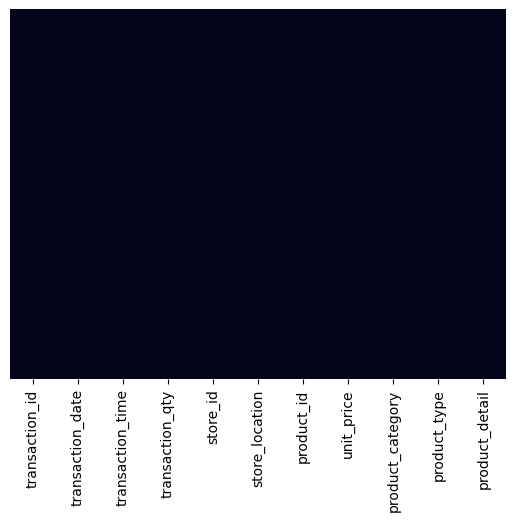

In [0]:
#visual check
import seaborn as sns
sns.heatmap(df.isnull(), cbar=False, yticklabels=False)

## Summary stats

In [0]:
# Numeric summary
df.describe()

,transaction_id,transaction_time,transaction_qty,store_id,product_id,unit_price
count,149116.000000,149116,149116.000000,149116.000000,149116.000000,149116.000000
mean,74737.371872,2026-02-28 12:14:15.815794688,1.438276,5.342063,47.918607,3.382219
min,1.000000,2026-02-28 06:00:00,1.000000,3.000000,1.000000,0.800000
25%,37335.750000,2026-02-28 09:05:10.500000,1.000000,3.000000,33.000000,2.500000
50%,74727.500000,2026-02-28 11:15:28,1.000000,5.000000,47.000000,3.000000
75%,112094.250000,2026-02-28 15:25:57,2.000000,8.000000,60.000000,3.750000
max,149456.000000,2026-02-28 20:59:32,8.000000,8.000000,87.000000,45.000000
std,43153.600016,NaN,0.542509,2.074241,17.930020,2.658723


In [0]:
# categorical summary
df.describe(include = "object")

,transaction_date,store_location,product_category,product_type,product_detail
count,149116,149116,149116,149116,149116
unique,181,3,9,29,80
top,2023-06-19,Hell's Kitchen,Coffee,Brewed Chai tea,Chocolate Croissant
freq,1343,50735,58416,17183,3076


In [0]:
# value counts for a column
df["product_category"].value_counts()

product_category
Coffee                58416
Tea                   45449
Bakery                22796
Drinking Chocolate    11468
Flavours               6790
Coffee beans           1753
Loose Tea              1210
Branded                 747
Packaged Chocolate      487
Name: count, dtype: int64

<Axes: xlabel='product_category'>

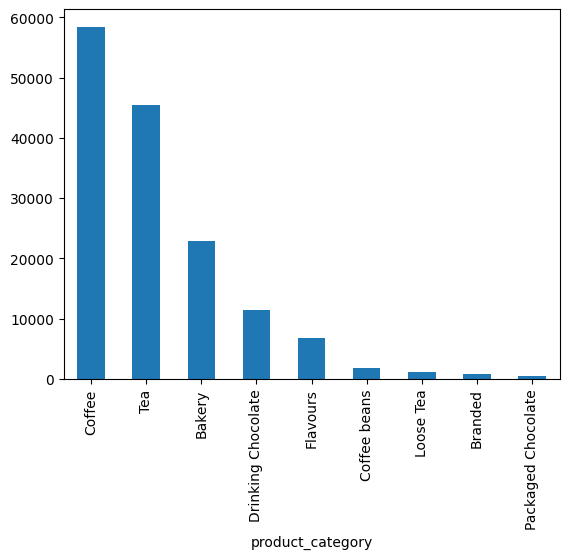

In [0]:
df["product_category"].value_counts().plot(kind="bar")

## Distribution

In [0]:
import matplotlib.pyplot as plt

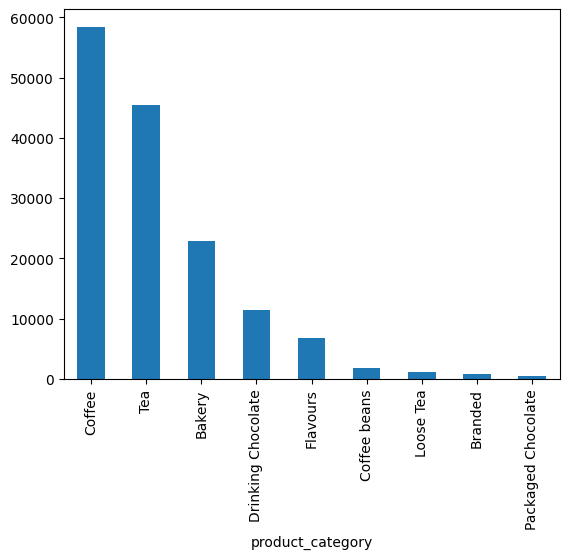

In [0]:
df["product_category"].value_counts().plot.bar() #matplotlib
plt.show()

## Relationships

In [0]:
df.corr(numeric_only=True, method = "spearman")

,transaction_id,transaction_qty,store_id,product_id,unit_price
transaction_id,1.000000,0.006562,-0.006079,0.000550,-0.002135
transaction_qty,0.006562,1.000000,0.007938,-0.174417,-0.160442
store_id,-0.006079,0.007938,1.000000,0.026123,-0.010181
product_id,0.000550,-0.174417,0.026123,1.000000,0.214682
unit_price,-0.002135,-0.160442,-0.010181,0.214682,1.000000


<Axes: >

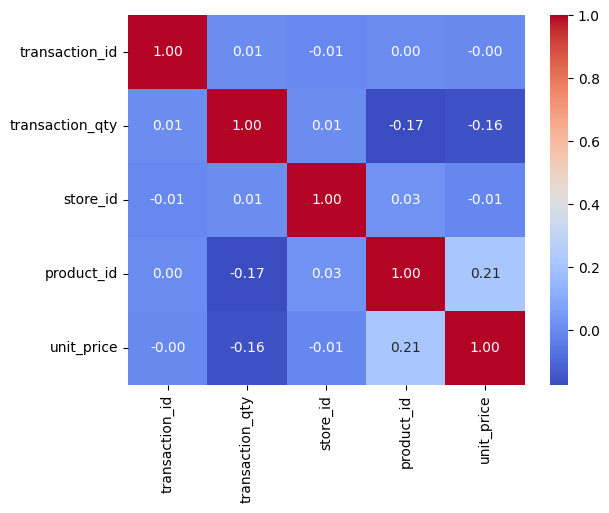

In [0]:
sns.heatmap(df.corr(numeric_only=True, method = "spearman"), annot=True, fmt=".2f", cmap="coolwarm")

## groupBy

# Viz library comparision

# Exercise